# 03 · Four levels and a sixteen-step palette

Distinguish palette remapping from genuine 16-level quantization, and show why lost intensity detail cannot be reconstructed from four codes.

**Inputs:** two web photographs, [NASA astronaut](https://scikit-image.org/docs/0.25.x/api/skimage.data.html#skimage.data.astronaut) and [coffee by Rachel Michetti](https://scikit-image.org/docs/0.25.x/api/skimage.data.html#skimage.data.coffee). Original files, source URLs, credits, and checksums are in [assets/](assets/). Both photographs are processed at their original dimensions.

**Group:** Nmertgules and Iliya.

The figures and measurements below are saved outputs from an actual execution. Use Restart Kernel and Run All to reproduce them.

## 1. Load and verify the photographs

The repository includes the images. If this notebook is opened alone in Colab, the same files are downloaded from the versioned URLs and checked against SHA-256 hashes.

In [1]:
%matplotlib inline
from pathlib import Path
from urllib.request import urlopen
import hashlib
import json
from time import perf_counter_ns

import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from matplotlib_inline.backend_inline import set_matplotlib_formats

set_matplotlib_formats("png")
plt.rcParams.update({
    "figure.dpi": 95, "font.family": "DejaVu Sans", "font.size": 10,
    "axes.titlesize": 11, "figure.facecolor": "white", "axes.spines.top": False,
    "axes.spines.right": False,
})
SOURCES = [{'name': 'astronaut', 'url': 'https://raw.githubusercontent.com/scikit-image/scikit-image/v0.25.2/skimage/data/astronaut.png', 'sha256': '88431cd9653ccd539741b555fb0a46b61558b301d4110412b5bc28b5e3ea6cb5', 'bytes': 791555, 'credit': 'NASA', 'license': 'Public domain', 'license_reference': 'https://scikit-image.org/docs/0.25.x/api/skimage.data.html#skimage.data.astronaut'}, {'name': 'coffee', 'url': 'https://raw.githubusercontent.com/scikit-image/scikit-image/v0.25.2/skimage/data/coffee.png', 'sha256': 'cc02f8ca188b167c775a7101b5d767d1e71792cf762c33d6fa15a4599b5a8de7', 'bytes': 466706, 'credit': 'Rachel Michetti, courtesy of Pikolo Espresso Bar', 'license': 'CC0 1.0', 'license_reference': 'https://scikit-image.org/docs/0.25.x/api/skimage.data.html#skimage.data.coffee'}]
# Works from the repository root, from week2/, and in a standalone Colab notebook.
asset_dir = next((p for p in (Path("assets"), Path("week2/assets"))
                  if p.is_dir()), Path("assets"))
asset_dir.mkdir(parents=True, exist_ok=True)
images = {}
for source in SOURCES:
    path = asset_dir / (source["name"] + ".png")
    if not path.is_file():
        with urlopen(source["url"], timeout=45) as response:
            path.write_bytes(response.read())
    raw = path.read_bytes()
    assert hashlib.sha256(raw).hexdigest() == source["sha256"], f"Photo checksum mismatch: {path.name}"
    bgr = cv2.imdecode(np.frombuffer(raw, dtype=np.uint8), cv2.IMREAD_COLOR)
    if bgr is None:
        raise ValueError(f"Cannot decode photograph: {path.name}")
    images[source["name"]] = {
        "rgb": cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB),
        "gray": cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY),
    }
    print(f"Loaded {source['name']}: {bgr.shape[1]} x {bgr.shape[0]} pixels; SHA-256 verified")

def show_table(headers, rows):
    lines = ["| " + " | ".join(headers) + " |", "| " + " | ".join(["---"] * len(headers)) + " |"]
    lines += ["| " + " | ".join(map(str, row)) + " |" for row in rows]
    display(Markdown("\n".join(lines)))

def show_image(ax, image, title, vmax=255):
    ax.imshow(image, cmap="gray" if image.ndim == 2 else None,
              vmin=0 if image.ndim == 2 else None,
              vmax=vmax if image.ndim == 2 else None, interpolation="nearest")
    ax.set_title(title)
    ax.axis("off")

def show_figure(fig):
    display(fig)
    plt.close(fig)

RESULTS = {}

Loaded astronaut: 512 x 512 pixels; SHA-256 verified
Loaded coffee: 600 x 400 pixels; SHA-256 verified


## 2. Method

First, four-level codes are floor(x/64). Map those codes to palette entries 0, 5, 10, and 15 of a 16-step palette, giving display values 0, 85, 170, and 255. A separate direct 16-level quantization uses the original image. Using the original pixel remainder after discarding it would introduce extra source information and would not be recovery from four levels.

In [2]:
def level_comparison(image):
    code4 = image // 64
    four = (code4 * 64).astype(np.uint8)
    palette16_indices = (code4 * 5).astype(np.uint8)
    remapped = (palette16_indices * 17).astype(np.uint8)
    direct16 = ((image // 16) * 16).astype(np.uint8)
    return four, remapped, direct16

## 3. Results on both photographs

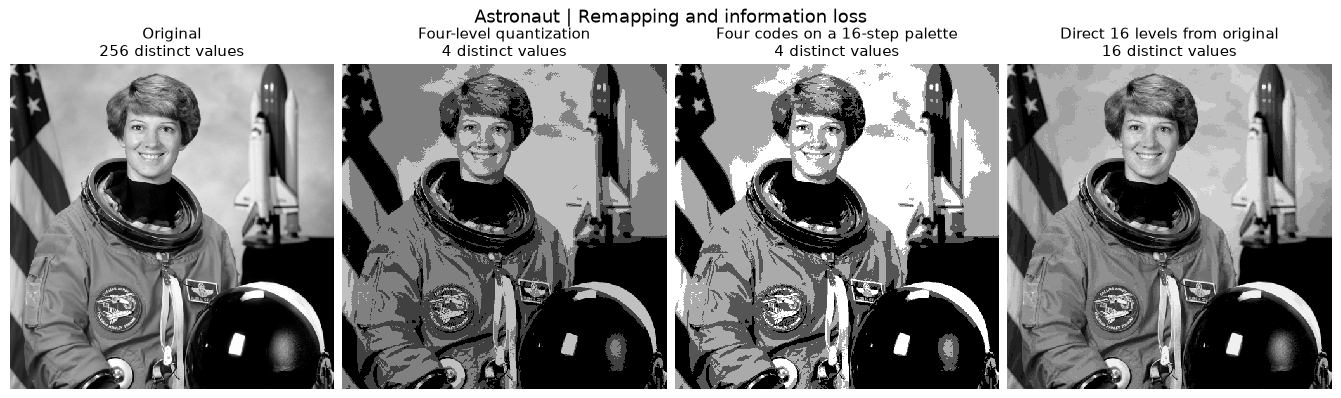

| Stage | Values used |
| --- | --- |
| Four levels | [0, 64, 128, 192] |
| Remapped | [0, 85, 170, 255] |
| Direct 16 levels | [0, 16, 32, 48, 64, 80, 96, 112, 128, 144, 160, 176, 192, 208, 224, 240] |

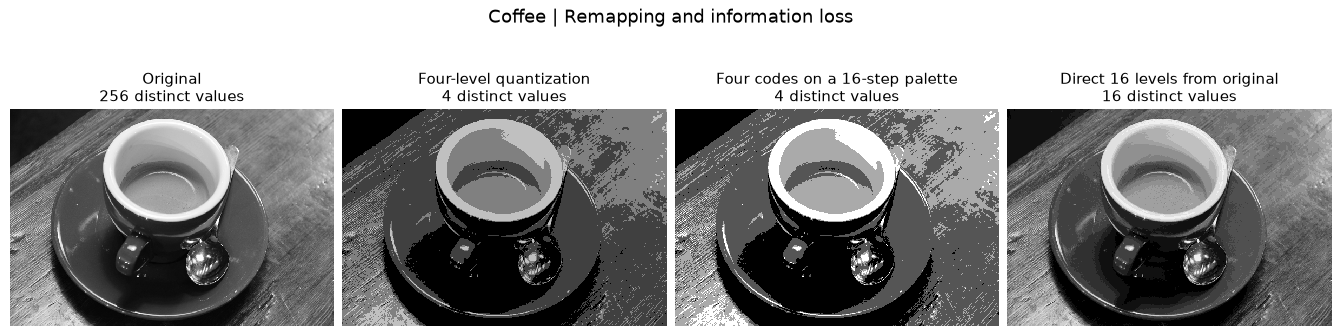

| Stage | Values used |
| --- | --- |
| Four levels | [0, 64, 128, 192] |
| Remapped | [0, 85, 170, 255] |
| Direct 16 levels | [0, 16, 32, 48, 64, 80, 96, 112, 128, 144, 160, 176, 192, 208, 224, 240] |

In [3]:
for name, photo in images.items():
    image = photo["gray"]
    four, remapped, direct16 = level_comparison(image)
    assert np.unique(four).size == np.unique(remapped).size <= 4
    assert set(np.unique(remapped).tolist()) <= {0, 85, 170, 255}
    fig, axes = plt.subplots(1, 4, figsize=(14, 4.2), layout="constrained")
    panels = [(image, "Original"), (four, "Four-level quantization"),
              (remapped, "Four codes on a 16-step palette"), (direct16, "Direct 16 levels from original")]
    for ax, (result, title) in zip(axes, panels):
        show_image(ax, result, f"{title}\n{np.unique(result).size} distinct values")
    fig.suptitle(name.title() + " | Remapping and information loss", fontsize=14)
    show_figure(fig)
    RESULTS[name] = {"four_level_values": np.unique(four).tolist(), "remapped_values": np.unique(remapped).tolist(), "direct16_values": np.unique(direct16).tolist()}
    show_table(["Stage", "Values used"], [["Four levels", RESULTS[name]["four_level_values"]],
        ["Remapped", RESULTS[name]["remapped_values"]], ["Direct 16 levels", RESULTS[name]["direct16_values"]]])

## 4. Interpretation

The remapped image has a wider display range but still only four distinct intensities. The direct 16-level image retains more tonal detail because it is computed from the original. A deterministic mapping of four input codes can produce at most four output values.

In [4]:
ramp = np.arange(256, dtype=np.uint8)
four, remapped, direct16 = level_comparison(ramp)
assert np.unique(four).size == np.unique(remapped).size == 4
assert np.unique(direct16).size == 16
assert four[0] == four[63] and remapped[0] == remapped[63]
print("PASS: remapping keeps four levels; direct quantization produces 16 on the full ramp.")

PASS: remapping keeps four levels; direct quantization produces 16 on the full ramp.
